In [342]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/HamedTabkhi/Intro-to-ML/main/Dataset/Housing.csv'

df = pd.DataFrame(pd.read_csv(url))
df.head()



,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [343]:
#Dataset setup
for c in ['mainroad', 'guestroom', 'basement', 'hotwaterheating','airconditioning', 'prefarea']:
    df[c] = df[c].map({'yes': 1, 'no': 0}).astype(int)


df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


In [344]:
#functions
def compute_cost(X, y, theta):

    predictions = X.dot(theta)
    errors = np.subtract(predictions, y)
    sqrErrors = np.square(errors)
    J = 1 / (2 * m) * np.sum(sqrErrors)

    return J

#gradient descent w/ training & validation
def gradient_descent(X_train, y_train, X_val, y_val, theta, alpha, iterations):
    m = len(y_train)
    train_cost_history = np.zeros(iterations)
    val_cost_history = np.zeros(iterations)

    for i in range(iterations):
        predictions = X_train.dot(theta)
        errors = np.subtract(predictions, y_train)
        sum_delta = (alpha / m) * X_train.transpose().dot(errors)
        theta = theta - sum_delta

        train_cost_history[i] = compute_cost(X_train, y_train, theta)
        val_cost_history[i] = compute_cost(X_val, y_val, theta)

    return theta, train_cost_history, val_cost_history




In [345]:
# initialization
m = len(df)
print(m)
iterations = 1000

# 80 training / 20 eval = 436 : 109
np.random.seed(163)
mix_idx = np.random.permutation(m)
train_idx = mix_idx[:int(m*0.8)] # 436 shuffled training rows - training
val_idx = mix_idx[int(m*0.8):] # 109 shuffled validation rows - validation

y_train = df['price'].values[train_idx].astype(float)
y_val = df['price'].values[val_idx].astype(float)

545


Problem 1a final theta: [4.49221488e-01 8.81158845e+02 1.67684362e+00 9.09358557e-01
 1.40890307e+00 4.47712400e-01]
Final training cost: 1258801809966.846
Final validation cost: 424689224120.94763





/tmp/ipykernel_9231/2140712993.py:6: RuntimeWarning: overflow encountered in square
  sqrErrors = np.square(errors)
/tmp/ipykernel_9231/2140712993.py:21: RuntimeWarning: invalid value encountered in subtract
  theta = theta - sum_delta


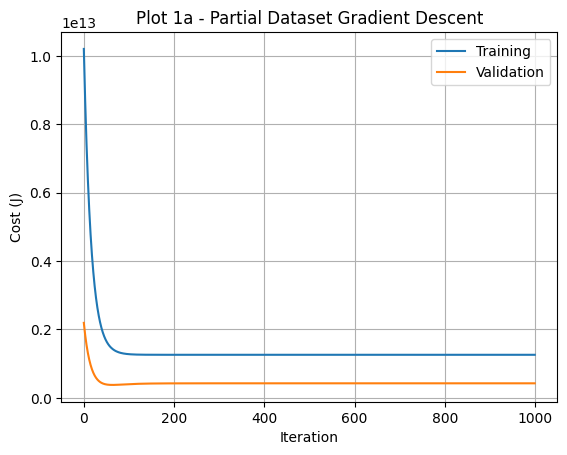

In [346]:
#1.a) - Gradient decent - area, bedrooms, bathrooms, stories, parking
vars_1a = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

#build set for 1a based on
X_train_1a = df[vars_1a].values[train_idx].astype(float)
X_val_1a = df[vars_1a].values[val_idx].astype(float)

X_train_1a = np.hstack((np.ones((X_train_1a.shape[0], 1)), X_train_1a))
X_val_1a = np.hstack((np.ones((X_val_1a.shape[0], 1)), X_val_1a))

for alpha in [0.01, 0.5, 0.1]:
  theta = np.zeros(X_train_1a.shape[1])
  theta, train_hist_1a, val_hist_1a = gradient_descent(X_train_1a, y_train, X_val_1a, y_val, theta, alpha, iterations)
  # print(f'alpha={alpha}  final train cost={train_hist_1a[-1]}  final val cost={val_hist_1a[-1]}')

# alphas are way too large for this gradient descent

alpha = 10**-9
theta_1a = np.zeros(X_train_1a.shape[1])
theta_1a, train_hist_1a, val_hist_1a = gradient_descent(X_train_1a, y_train, X_val_1a, y_val, theta_1a, alpha, iterations)
print('Problem 1a final theta:', theta_1a)
print('Final training cost:', train_hist_1a[-1])
print('Final validation cost:', val_hist_1a[-1])
print("\n" * 2)

plt.plot(range(iterations), train_hist_1a, label='Training')
plt.plot(range(iterations), val_hist_1a, label='Validation')
plt.xlabel('Iteration')
plt.ylabel('Cost (J)')
plt.title('Plot 1a - Partial Dataset Gradient Descent')
plt.legend()
plt.grid(True)
plt.show()




Problem 1b final theta: [4.49221438e-01 8.81158735e+02 1.67684346e+00 9.09358492e-01
 1.40890297e+00 3.95157640e-01 1.78646799e-01 2.54283185e-01
 6.15159576e-02 3.65324227e-01 4.47712365e-01 1.82168355e-01]
Final training cost: 1258801551095.5186
Final validation cost: 424689120424.0789


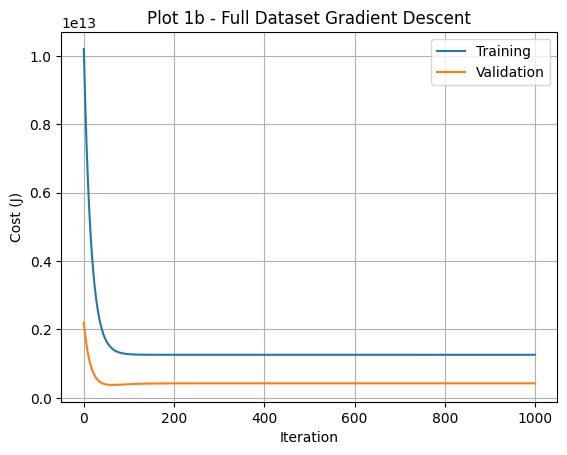

In [347]:
#1.b) - full dataset gradient decent
vars_1b = ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating','airconditioning', 'parking', 'prefarea']

X_train_1b = df[vars_1b].values[train_idx].astype(float)
X_val_1b = df[vars_1b].values[val_idx].astype(float)

X_train_1b = np.hstack((np.ones((X_train_1b.shape[0], 1)), X_train_1b))
X_val_1b = np.hstack((np.ones((X_val_1b.shape[0], 1)), X_val_1b))

#alpha reused from 1a
theta_1b = np.zeros(X_train_1b.shape[1])
theta_1b, train_hist_1b, val_hist_1b = gradient_descent(X_train_1b, y_train, X_val_1b, y_val, theta_1b, alpha, iterations)

print('Problem 1b final theta:', theta_1b)
print('Final training cost:', train_hist_1b[-1])
print('Final validation cost:', val_hist_1b[-1])

plt.plot(range(iterations), train_hist_1b, label='Training')
plt.plot(range(iterations), val_hist_1b, label='Validation')
plt.xlabel('Iteration')
plt.ylabel('Cost (J)')
plt.title('Plot 1b - Full Dataset Gradient Descent')
plt.legend()
plt.grid(True)
plt.show()


Standardization final training cost: 600574393455.3384  final validation cost: 173717133286.7144
Normalization final training cost: 780487480372.0887  final validation cost: 162100158047.11594


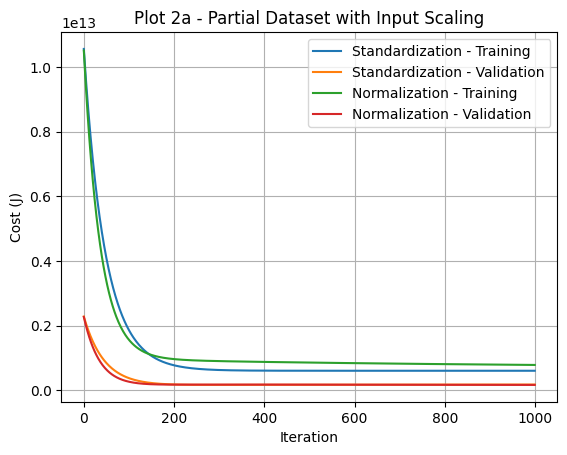

In [348]:
#2a) - 1a w/ scaling - standardization and normalization
X_train_2a_raw = df[vars_1a].values[train_idx].astype(float)
X_val_2a_raw = df[vars_1a].values[val_idx].astype(float)

#standardization = (x - mean) / standard deviation
mean_2a = X_train_2a_raw.mean(axis=0)
std_2a = X_train_2a_raw.std(axis=0)
X_train_2a_std = (X_train_2a_raw - mean_2a) / std_2a
X_val_2a_std = (X_val_2a_raw - mean_2a) / std_2a

#normalization = (x - min) / (max - min)
min_2a = X_train_2a_raw.min(axis=0)
max_2a = X_train_2a_raw.max(axis=0)
X_train_2a_norm = (X_train_2a_raw - min_2a) / (max_2a - min_2a)
X_val_2a_norm = (X_val_2a_raw - min_2a) / (max_2a - min_2a)

X_train_2a_std = np.hstack((np.ones((X_train_2a_std.shape[0], 1)), X_train_2a_std))
X_val_2a_std = np.hstack((np.ones((X_val_2a_std.shape[0], 1)), X_val_2a_std))
X_train_2a_norm = np.hstack((np.ones((X_train_2a_norm.shape[0], 1)), X_train_2a_norm))
X_val_2a_norm = np.hstack((np.ones((X_val_2a_norm.shape[0], 1)), X_val_2a_norm))

alpha = .01
theta_std = np.zeros(X_train_2a_std.shape[1])
theta_norm = np.zeros(X_train_2a_norm.shape[1])

theta_std, train_hist_2a_std, val_hist_2a_std = gradient_descent(X_train_2a_std, y_train, X_val_2a_std, y_val, theta_std, alpha, iterations)
theta_norm, train_hist_2a_norm, val_hist_2a_norm = gradient_descent(X_train_2a_norm, y_train, X_val_2a_norm, y_val, theta_norm, alpha, iterations)

print('Standardization final training cost:', train_hist_2a_std[-1], ' final validation cost:', val_hist_2a_std[-1])
print('Normalization final training cost:', train_hist_2a_norm[-1], ' final validation cost:', val_hist_2a_norm[-1])

plt.plot(range(iterations), train_hist_2a_std, label='Standardization - Training')
plt.plot(range(iterations), val_hist_2a_std, label='Standardization - Validation')
plt.plot(range(iterations), train_hist_2a_norm, label='Normalization - Training')
plt.plot(range(iterations), val_hist_2a_norm, label='Normalization - Validation')
plt.xlabel('Iteration')
plt.ylabel('Cost (J)')
plt.title('Plot 2a - Partial Dataset with Input Scaling')
plt.legend()
plt.grid(True)
plt.show()

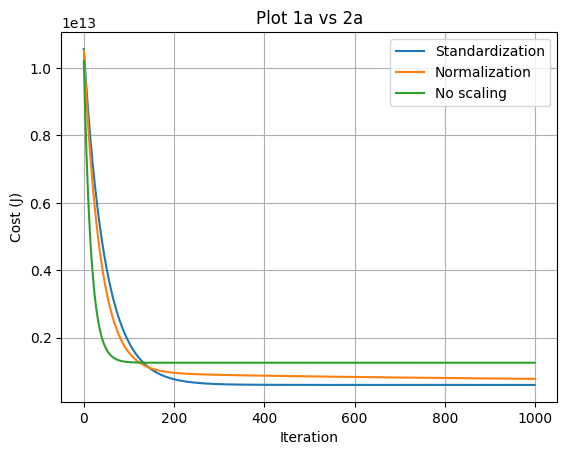

In [349]:
# 1a vs 2a Training
plt.plot(range(iterations), train_hist_2a_std, label='Standardization')
plt.plot(range(iterations), train_hist_2a_norm, label='Normalization')
plt.plot(range(iterations), train_hist_1a, label='No scaling')
plt.xlabel('Iteration')
plt.ylabel('Cost (J)')
plt.title('Plot 1a vs 2a')
plt.legend()
plt.grid(True)
plt.show()

Standardization final training cost: 446939893891.6791  final validation cost: 131422711776.23456
Normalization final training cost: 585671099617.4913  final validation cost: 110750811052.50633


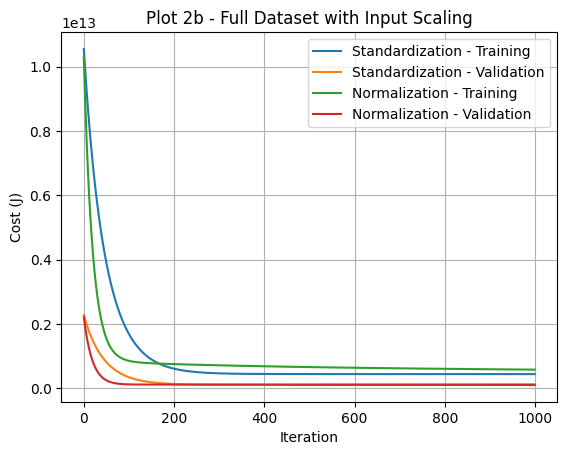

In [350]:
#2b) - 1b w/ scaling - standardization and normalization
X_train_2b_raw = df[vars_1b].values[train_idx].astype(float)
X_val_2b_raw = df[vars_1b].values[val_idx].astype(float)

#standardization = (x - mean) / standard deviation
mean_2b = X_train_2b_raw.mean(axis=0)
std_2b = X_train_2b_raw.std(axis=0)
X_train_2b_std = (X_train_2b_raw - mean_2b) / std_2b
X_val_2b_std = (X_val_2b_raw - mean_2b) / std_2b

#normalization = (x - min) / (max - min)
min_2b = X_train_2b_raw.min(axis=0)
max_2b = X_train_2b_raw.max(axis=0)
X_train_2b_norm = (X_train_2b_raw - min_2b) / (max_2b - min_2b)
X_val_2b_norm = (X_val_2b_raw - min_2b) / (max_2b - min_2b)

X_train_2b_std = np.hstack((np.ones((X_train_2b_std.shape[0], 1)), X_train_2b_std))
X_val_2b_std = np.hstack((np.ones((X_val_2b_std.shape[0], 1)), X_val_2b_std))
X_train_2b_norm = np.hstack((np.ones((X_train_2b_norm.shape[0], 1)), X_train_2b_norm))
X_val_2b_norm = np.hstack((np.ones((X_val_2b_norm.shape[0], 1)), X_val_2b_norm))

alpha = 0.01
theta_std = np.zeros(X_train_2b_std.shape[1])
theta_norm = np.zeros(X_train_2b_norm.shape[1])

theta_std, train_hist_2b_std, val_hist_2b_std = gradient_descent(X_train_2b_std, y_train, X_val_2b_std, y_val, theta_std, alpha, iterations)
theta_norm, train_hist_2b_norm, val_hist_2b_norm = gradient_descent(X_train_2b_norm, y_train, X_val_2b_norm, y_val, theta_norm, alpha, iterations)

print('Standardization final training cost:', train_hist_2b_std[-1], ' final validation cost:', val_hist_2b_std[-1])
print('Normalization final training cost:', train_hist_2b_norm[-1], ' final validation cost:', val_hist_2b_norm[-1])

plt.plot(range(iterations), train_hist_2b_std, label='Standardization - Training')
plt.plot(range(iterations), val_hist_2b_std, label='Standardization - Validation')
plt.plot(range(iterations), train_hist_2b_norm, label='Normalization - Training')
plt.plot(range(iterations), val_hist_2b_norm, label='Normalization - Validation')
plt.xlabel('Iteration')
plt.ylabel('Cost (J)')
plt.title('Plot 2b - Full Dataset with Input Scaling')
plt.legend()
plt.grid(True)
plt.show()

In [351]:
# gradient descent function modified for ridge regularization
# reg_term = (reg_lambda/m) * theta => delta = reg_term * alpha
def gradient_descent_ridge(X_train, y_train, X_val, y_val, theta, alpha, iterations, reg_lambda):
    m = len(y_train)
    train_cost_history = np.zeros(iterations)
    val_cost_history = np.zeros(iterations)

    for i in range(iterations):
        predictions = X_train.dot(theta)
        errors = np.subtract(predictions, y_train)
        sum_delta = (alpha / m) * X_train.transpose().dot(errors)

        # regularization
        reg_term = (reg_lambda / m) * theta
        reg_term[0] = 0    # bias to 0
        sum_delta = sum_delta + alpha * reg_term

        theta = theta - sum_delta

        train_cost_history[i] = compute_cost(X_train, y_train, theta)
        val_cost_history[i] = compute_cost(X_val, y_val, theta)

    return theta, train_cost_history, val_cost_history

Problem 3a final theta: [4735722.13916928   66218.68402212   44863.62558961   74752.32353124
  100254.60986388   83402.26190056]
Final training cost: 1416372434102.1963
Final validation cost: 266108082900.54892


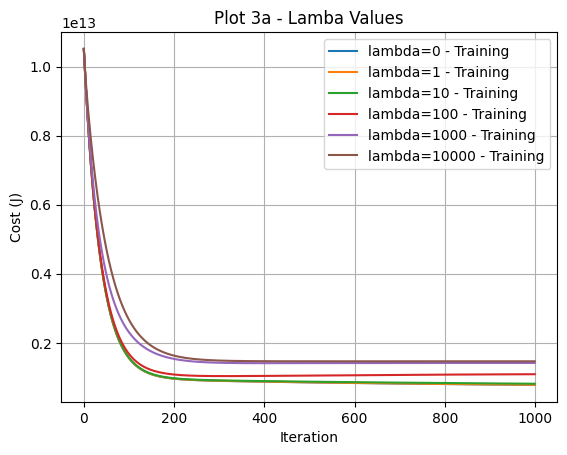

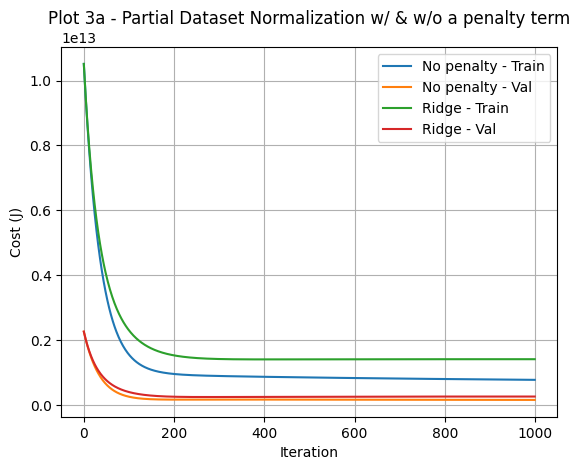

In [352]:
#3a) - 1a with Normalization and a penalty term

for reg_lambda in [0, 1, 10, 100, 1000, 10000]:
  theta_3a = np.zeros(X_train_2a_norm.shape[1])
  theta_3a, train_hist_3a, val_hist_3a = gradient_descent_ridge(X_train_2a_norm, y_train, X_val_2a_norm, y_val, theta_3a, alpha, iterations, reg_lambda)
  plt.plot(range(iterations), train_hist_3a, label=f'lambda={reg_lambda} - Training')
plt.xlabel('Iteration')
plt.ylabel('Cost (J)')
plt.title('Plot 3a - Lamba Values')
plt.legend()
plt.grid(True)
plt.show

reg_lambda = 1000
theta_3a = np.zeros(X_train_2a_norm.shape[1])
theta_3a, train_hist_3a, val_hist_3a = gradient_descent_ridge(X_train_2a_norm, y_train, X_val_2a_norm, y_val, theta_3a, alpha, iterations, reg_lambda)

print('Problem 3a final theta:', theta_3a)
print('Final training cost:', train_hist_3a[-1])
print('Final validation cost:', val_hist_3a[-1])

plt.figure()
plt.plot(range(iterations), train_hist_2a_norm, label='No penalty - Train')
plt.plot(range(iterations), val_hist_2a_norm, label='No penalty - Val')
plt.plot(range(iterations), train_hist_3a, label='Ridge - Train')
plt.plot(range(iterations), val_hist_3a, label='Ridge - Val')
plt.xlabel('Iteration')
plt.ylabel('Cost (J)')
plt.title('Plot 3a - Partial Dataset Normalization w/ & w/o a penalty term')
plt.legend()
plt.grid(True)
plt.show()


Problem 3b final theta: [4556466.35480796   64661.66335093   45104.75722797   73567.6705764
   98601.8109551    75386.81495446   72730.13470543   62885.6038578
   23706.36346361  153793.91952941   81473.6212037    97456.73004594]
Final train cost: 1324226337836.8767
Final val cost: 242324715198.6721


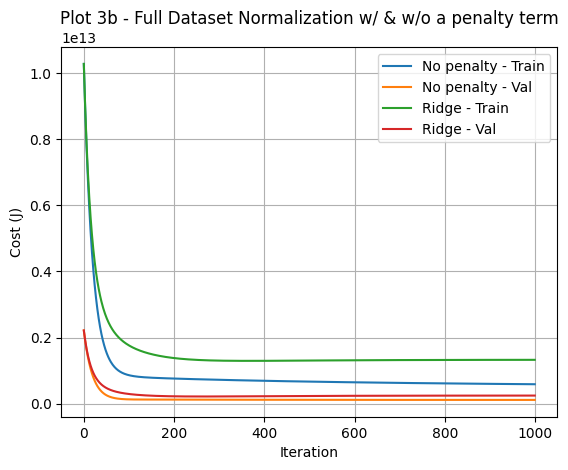

In [353]:
#3b - 1b with Normalization and a penalty term
theta_3b = np.zeros(X_train_2b_norm.shape[1])

reg_lambda = 1000
theta_3b, train_hist_3b, val_hist_3b = gradient_descent_ridge(X_train_2b_norm, y_train, X_val_2b_norm, y_val, theta_3b, alpha, iterations, reg_lambda)

print('Problem 3b final theta:', theta_3b)
print('Final train cost:', train_hist_3b[-1])
print('Final val cost:', val_hist_3b[-1])

plt.plot(range(iterations), train_hist_2b_norm, label='No penalty - Train')
plt.plot(range(iterations), val_hist_2b_norm, label='No penalty - Val')
plt.plot(range(iterations), train_hist_3b, label='Ridge - Train')
plt.plot(range(iterations), val_hist_3b, label='Ridge - Val')
plt.xlabel('Iteration')
plt.ylabel('Cost (J)')
plt.title('Plot 3b - Full Dataset Normalization w/ & w/o a penalty term')
plt.legend()
plt.grid(True)
plt.show()